In [ ]:
# 제출 안내
# 교재 Ch03-1, 03-2, 03-3 실습 노트북 각 완성. 
# 각 모델의 train/test R² 출력 셀 포함. Ridge alpha 탐색 그래프 1개 포함.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [5]:
# 데이터 수집
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])


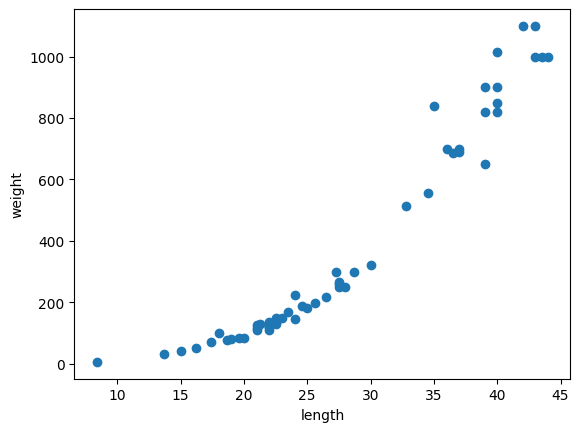

In [6]:
# 시각화
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [10]:
train_input, test_input, train_target,test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [ ]:
# 차원 이해
test_array = np.array([1,2,3,4])
print(test_array)
test_array= test_array.reshape(2,2)
print(test_array)

[1 2 3 4]


In [ ]:
# reshape 괄호 안 첫번째 위치(크기)에 -1을 넣으면 다른 차원을 채우고 남은 원소에 맞게 차원을 지정하라는 의미이다.

train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)
print(train_input.shape, test_input.shape)

# 2차원 배열 성공!

(42, 1) (14, 1)


In [21]:
# 결정계수(R**2)
# KNeighborsRegressor

knr = KNeighborsRegressor()

# k-최근접 이웃 회귀 모델을 훈련합니다.
knr.fit(train_input, train_target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# 테스트 점수 확인!
print(knr.score(test_input, test_target))

0.992809406101064


In [ ]:
# 아주 좋은 점수가 나옴!!!!
# 분류의 경우에는 테스트 샘플에 있는 샘플을 정확하게 분류한 개수의 비율이지만, 
# 회귀에서는 예측하는 값이나 타깃 모두 임의의 수치이므로 정확한 숫자를 맞힌다는 것은 불가능합니다.
# 그런데 R**2인 결정계수는 솔직히 머라는지 감이 안 오므로 다른 값을 계산해보자구 하네.
# 타깃과 예측한 값 사이의 차이를 구해보면 어느정도 예측이 벗어났는지 가늠하기 쉽다고 한다.
# 이제, mean absolute error는 타깃과 예측의 절댓값 오차를 평균하여 반환합니다.

In [27]:
# mean_absolute_error~~~~~
from sklearn.metrics import mean_absolute_error

# (1) 테스트 세트에 대한 예측을 만듭니다.
test_prediction = knr.predict(test_input)

# (2) 테스트 세트에 대한 평균 절댓값 오차를 계산합니다.
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


In [28]:
# 위의 19가 의미하는 바는 결과에서 예측이 평균적으로 19g 정도 타깃과 다르다는 점이 있다.
# 지금까지는 훈련 세트로 훈련하고 테스트 세트로 모델을 평가
# 그런데 이번에는 훈련 세트를 사용해서 평가해보자.

In [29]:
# 이 말은 즉 score() 메서드에 훈련 세트를 전달하여 점수를 출력하는 것이다.
print(knr.score(train_input, train_target))

0.9698823289099254


In [ ]:
#  아니 그런데 훈련 점수가 테스트 점수보다 낮게 나왔다,,,,,,, ->>> 과소적합
# 이런 상황을 통해 과대적합, 과소적합 개념을 말할 수 있다.
# 과대적합: 훈련 결과 굿, 테스트 결과 배드: 훈련세트에만 너무 잘 맞아서 새로운 샘플 예측이 잘 안되는 경우
# 과소적합: 훈련 결과 배드, 테스트 결과 굿:모델이 너무 단순하여 훈련 세트에 적절히 훈련되지 않은 경우

In [30]:
# 과소적합은 훈련세트를 조금더 복잡하게 만들면 된다.
# knn 알고리즘의 복잡하게 만드는 방법은 이웃의 개수인 k의 개수를 줄이는 것이다. 이러면 국지적인패턴에 민감해지고
# 이웃의 개수를 늘리면 데이터 전반에 있는 일반적인 패턴을 따른다.
# 사이킷런의 k기본값은 5니까 3으로 줄여보자.

In [32]:
# k 개수 3으로 설정
knr.n_neighbors = 3

# 모델을 다시 훈련합니다/
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))

0.9804899950518966


In [33]:
# 오~~~~상승햇다. 그럼 테스트의 결과는??
print(knr.score(test_input, test_target))

0.9746459963987609


In [ ]:
# 이제 테스트 결과가 훈련 결과보다 낮아졌으니 과소적합 문제는 해결했다. 
# 또한, 차이가 크지 않아서 과대적합도 아닌 거 같다고 한다.

In [ ]:
#  회귀 문제 다루기
# 농어의 길이등의 수치로 무게를 예측하는 것.

In [36]:
# 이로서 ch-03-01 end...

In [ ]:
# ch-03-02의 시작!
# 선형회귀

In [ ]:
# 농어무게를 예측하는 KNN 회귀모델을 보고하니까 클라이언트가 갑자기 길이가 50cm인 농어를 가져왔다!
# 역시 클라이언트는 개념이.없
# 그리고 농어의 길이를 50cm로 설정하고 회귀 모델로 예측을 하니 결과가 너무 차이가 났다,,,,,ㅈ
# 이를 통해 우리는 KNN의 한계를 알 수 있다.
# 